In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, norm
from scipy.optimize import minimize

### 1. Load Data

In [2]:
START_DATE = "2023-01-04"  

airpa_df = pd.read_csv("../../data/Secteur_Aerospace/AIR.PA.csv")
airpa_df = airpa_df[["Date", "Adj Close"]].copy()
airpa_df.columns = ["Date", "X_t"]

ampa_df = pd.read_csv("../../data/Secteur_Aerospace/AM.PA.csv")
ampa_df = ampa_df[["Date", "Adj Close"]].copy()
ampa_df.columns = ["Date", "X_t"]

### 2. Clean Data

**Convert date format**

In [3]:
airpa_df["Date"] = pd.to_datetime(airpa_df["Date"])
airpa_df = airpa_df[airpa_df["Date"] >= pd.Timestamp(START_DATE)].copy()
airpa_df = airpa_df.sort_values("Date").dropna().reset_index(drop=True)

ampa_df["Date"] = pd.to_datetime(ampa_df["Date"])
ampa_df = ampa_df[ampa_df["Date"] >= pd.Timestamp(START_DATE)].copy()
ampa_df = ampa_df.sort_values("Date").dropna().reset_index(drop=True)

print(airpa_df.shape)
print(ampa_df.shape)

(785, 2)
(785, 2)


### 3. Compute the Hanning Filter

$$
Y_t = \frac{1}{4} X_{t-1} + \frac{1}{2} X_t + \frac{1}{4} X_{t+1}
$$

In [4]:
airpa_df["Y_t"] = (
    0.25 * airpa_df["X_t"].shift(1) +
    0.50 * airpa_df["X_t"] +
    0.25 * airpa_df["X_t"].shift(-1)
)

ampa_df["Y_t"] = (
    0.25 * ampa_df["X_t"].shift(1) +
    0.50 * ampa_df["X_t"] +
    0.25 * ampa_df["X_t"].shift(-1)
)

# Drop first and last missing values caused by shift
airpa_df = airpa_df.dropna().reset_index(drop=True)
ampa_df = ampa_df.dropna().reset_index(drop=True)

**Plot Raw Series vs Filtered Series**

#### AIR.PA

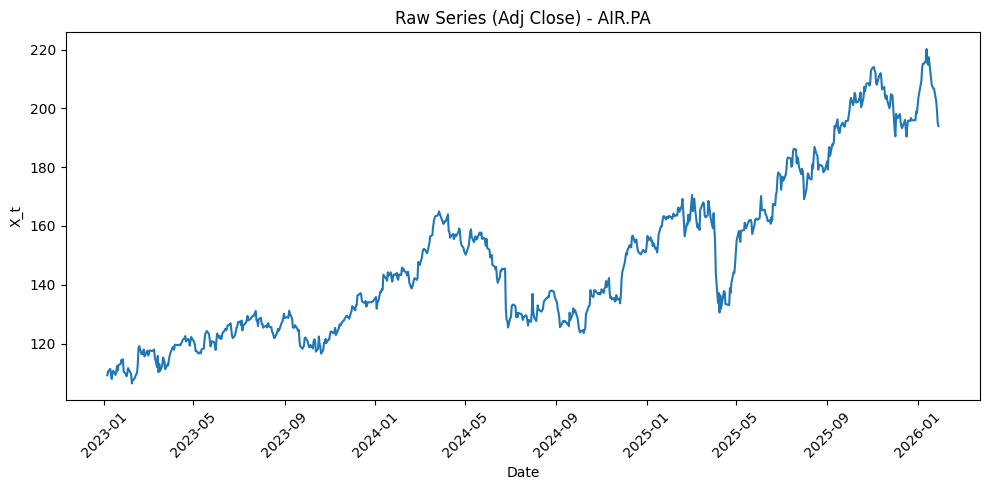

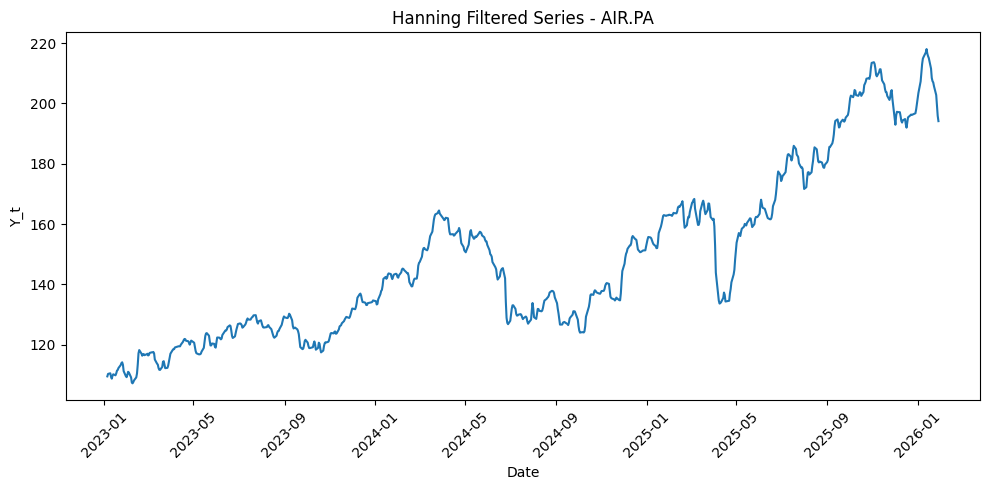

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(airpa_df["Date"], airpa_df["X_t"])
plt.title(f"Raw Series (Adj Close) - AIR.PA")
plt.xlabel("Date")
plt.ylabel("X_t")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(airpa_df["Date"], airpa_df["Y_t"])
plt.title(f"Hanning Filtered Series - AIR.PA")
plt.xlabel("Date")
plt.ylabel("Y_t")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### AM.PA

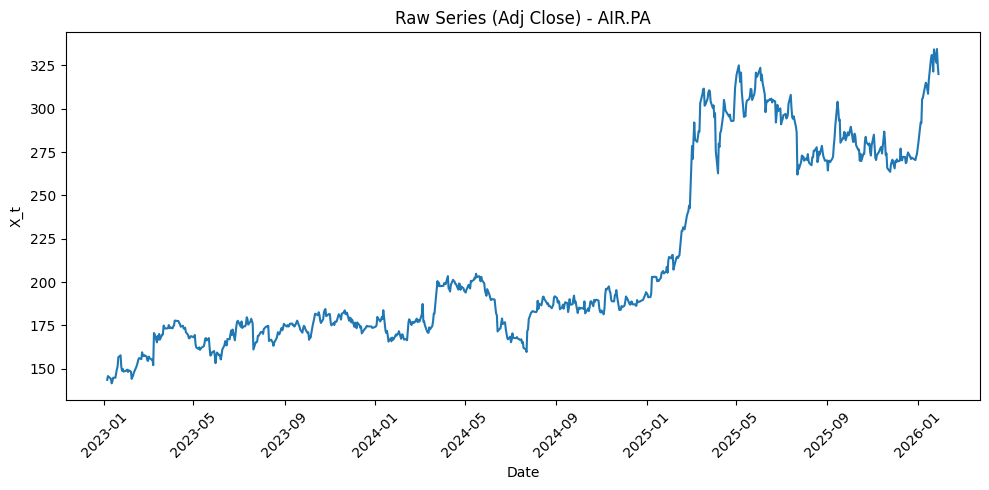

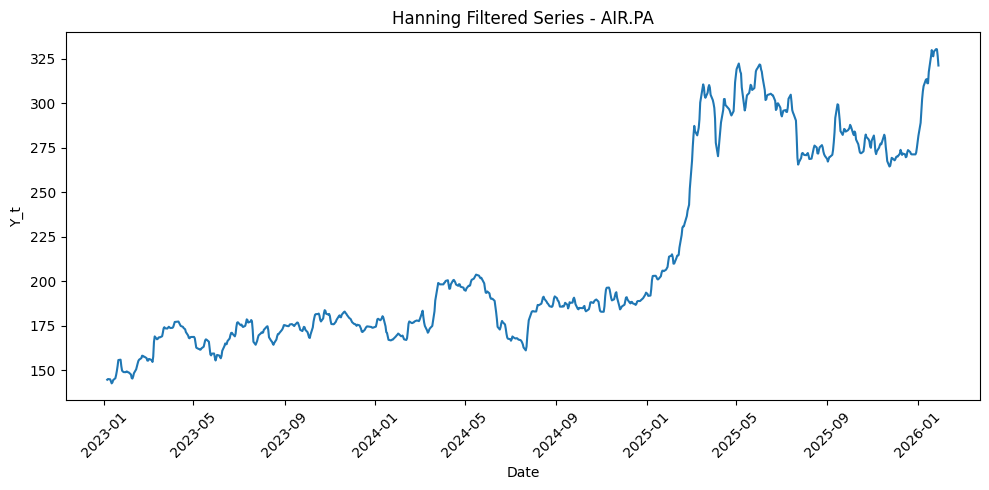

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(ampa_df["Date"], ampa_df["X_t"])
plt.title(f"Raw Series (Adj Close) - AIR.PA")
plt.xlabel("Date")
plt.ylabel("X_t")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(ampa_df["Date"], ampa_df["Y_t"])
plt.title(f"Hanning Filtered Series - AIR.PA")
plt.xlabel("Date")
plt.ylabel("Y_t")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### To ensure reliable estimation and avoid instability due to very small samples, 
### we restrict the candidate rupture points to k ∈ {30, ..., n - 30}.

## AIR.PA

### 4. KS Scan Over k

In [7]:
Y = airpa_df["Y_t"].to_numpy()
n = len(Y)

k_values = []
ks_stats = []
p_values = []

for k in range(30, n - 29):   # Python end is exclusive, so this gives 4,...,n-4
    sample1 = Y[:k]
    sample2 = Y[k:]

    stat, pval = ks_2samp(sample1, sample2)

    k_values.append(k)
    ks_stats.append(stat)
    p_values.append(pval)

best_index = int(np.argmax(ks_stats))
k_hat = k_values[best_index]
best_ks = float(ks_stats[best_index])
best_pval = float(p_values[best_index])
break_date = airpa_df.loc[k_hat, "Date"]

print("\nBest rupture point from KS scan")
print("k_hat      =", k_hat)
print("break_date =", break_date.date())
print("KS stat    =", best_ks)
print("p-value    =", best_pval)


Best rupture point from KS scan
k_hat      = 628
break_date = 2025-06-24
KS stat    = 1.0
p-value    = 3.5664768649755256e-168


**KS Scan Plot**

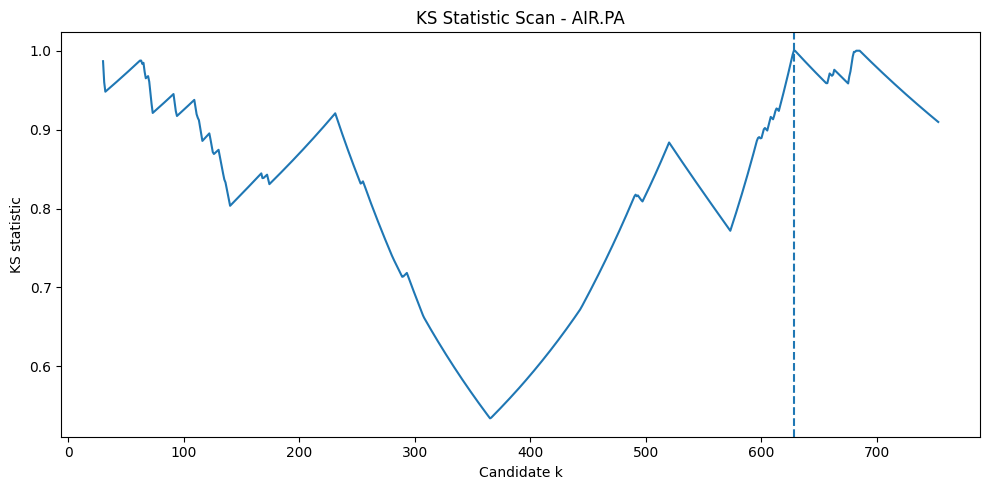

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(k_values, ks_stats)
plt.axvline(k_hat, linestyle="--")
plt.title(f"KS Statistic Scan - AIR.PA")
plt.xlabel("Candidate k")
plt.ylabel("KS statistic")
plt.tight_layout()
plt.show()

**Breakpoint Plot**

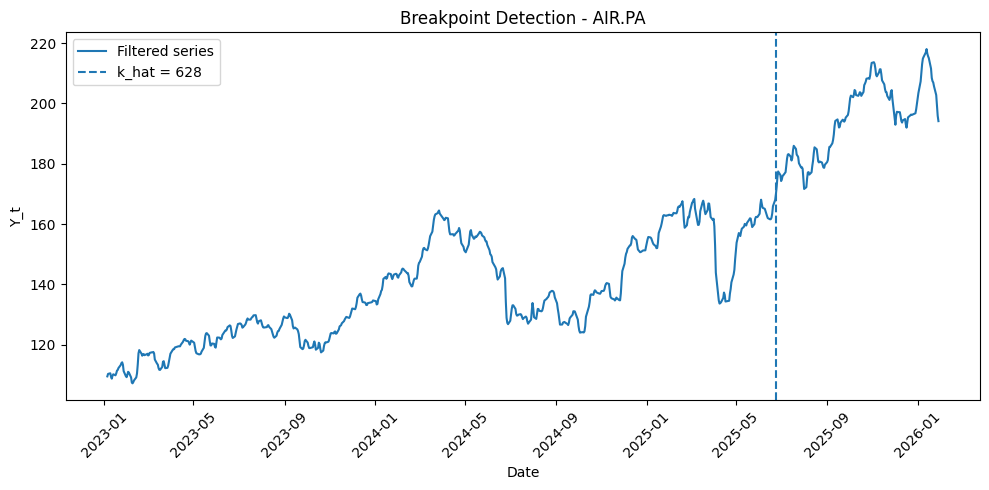

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(airpa_df["Date"], airpa_df["Y_t"], label="Filtered series")
plt.axvline(break_date, linestyle="--", label=f"k_hat = {k_hat}")
plt.title(f"Breakpoint Detection - AIR.PA")
plt.xlabel("Date")
plt.ylabel("Y_t")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### 5. Split and Estimate Skew Normal Parameters

In [10]:
y1 = Y[:k_hat]
y2 = Y[k_hat:]

print("\nSegment sizes")
print("Before rupture:", len(y1))
print("After rupture :", len(y2))

def skew_normal_pdf(x, mu, sigma, theta):
    z = (x - mu) / sigma
    return (2.0 / sigma) * norm.pdf(z) * norm.cdf(theta * z)


def neg_loglik_common_theta(params, y_left, y_right):
    """
    params = [mu1, log_sigma1, mu2, log_sigma2, theta]
    sigma1 = exp(log_sigma1), sigma2 = exp(log_sigma2)
    Common theta across both segments, as required by Sujet 3.
    """
    mu1, log_sigma1, mu2, log_sigma2, theta = params

    sigma1 = np.exp(log_sigma1)
    sigma2 = np.exp(log_sigma2)

    # Safety against invalid values
    if sigma1 <= 0 or sigma2 <= 0 or not np.isfinite(theta):
        return np.inf

    pdf1 = skew_normal_pdf(y_left, mu1, sigma1, theta)
    pdf2 = skew_normal_pdf(y_right, mu2, sigma2, theta)

    # Numerical stability
    eps = 1e-12
    pdf1 = np.clip(pdf1, eps, None)
    pdf2 = np.clip(pdf2, eps, None)

    ll = np.sum(np.log(pdf1)) + np.sum(np.log(pdf2))
    return -ll



Segment sizes
Before rupture: 628
After rupture : 155


In [11]:
# Initial values
mu1_init = float(np.mean(y1))
mu2_init = float(np.mean(y2))
sigma1_init = float(np.std(y1, ddof=0))
sigma2_init = float(np.std(y2, ddof=0))

# Avoid zero std
sigma1_init = max(sigma1_init, 1e-3)
sigma2_init = max(sigma2_init, 1e-3)

theta_init = 0.0

x0 = np.array([
    mu1_init,
    np.log(sigma1_init),
    mu2_init,
    np.log(sigma2_init),
    theta_init
])

result = minimize(
    neg_loglik_common_theta,
    x0=x0,
    args=(y1, y2),
    method="L-BFGS-B"
)

if not result.success:
    print("\nWarning: optimization did not fully converge.")
    print("Message:", result.message)

mu1_hat, log_sigma1_hat, mu2_hat, log_sigma2_hat, theta_hat = result.x
sigma1_hat = float(np.exp(log_sigma1_hat))
sigma2_hat = float(np.exp(log_sigma2_hat))
mu1_hat = float(mu1_hat)
mu2_hat = float(mu2_hat)
theta_hat = float(theta_hat)

print("\nJoint MLE estimates with common theta")
print("mu1    =", mu1_hat)
print("sigma1 =", sigma1_hat)
print("mu2    =", mu2_hat)
print("sigma2 =", sigma2_hat)
print("theta  =", theta_hat)
print("NegLogLik =", float(result.fun))


Joint MLE estimates with common theta
mu1    = 137.11864084394904
sigma1 = 16.525943790695116
mu2    = 194.33
sigma2 = 12.578285561287371
theta  = 0.0
NegLogLik = 3264.9815052806853


In [12]:
verdict = "Reject H0" if best_pval < 0.05 else "Fail to reject H0"

print("\nVerdict:", verdict)


Verdict: Reject H0


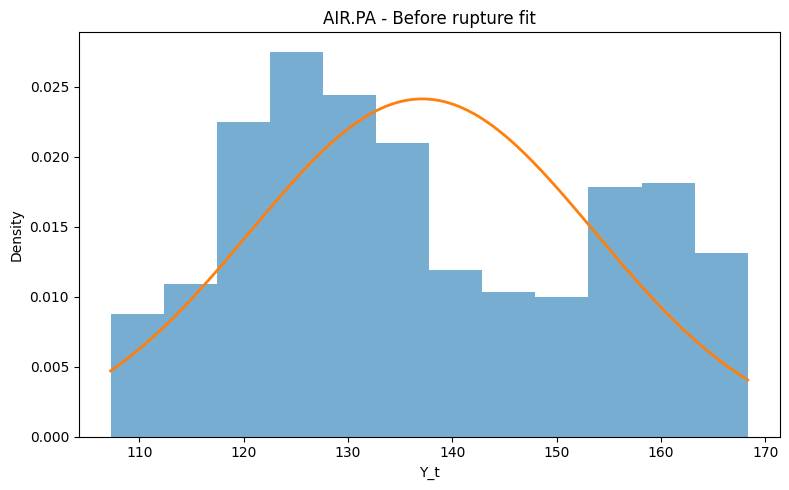

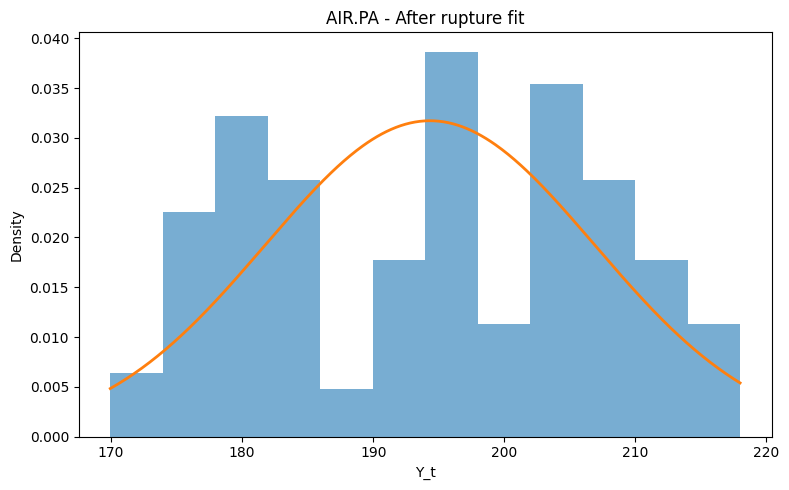

In [13]:
def plot_segment_fit(data, mu, sigma, theta, title):
    x_grid = np.linspace(np.min(data), np.max(data), 400)
    y_pdf = skew_normal_pdf(x_grid, mu, sigma, theta)

    plt.figure(figsize=(8, 5))
    plt.hist(data, bins=12, density=True, alpha=0.6)
    plt.plot(x_grid, y_pdf, linewidth=2)
    plt.title(title)
    plt.xlabel("Y_t")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

plot_segment_fit(y1, mu1_hat, sigma1_hat, theta_hat, f"AIR.PA - Before rupture fit")
plot_segment_fit(y2, mu2_hat, sigma2_hat, theta_hat, f"AIR.PA - After rupture fit")

### Interpretation

In [14]:
def build_interpretation_short(company):
    return (
        f"For {company}, the estimated rupture point is k_hat = {k_hat} "
        f"({break_date.date()}). The KS statistic is {best_ks:.4f} and the "
        f"p-value is {best_pval:.4f}, so the decision is: {verdict}. "
        f"The joint MLE estimates are mu1 = {mu1_hat:.4f}, sigma1 = {sigma1_hat:.4f}, "
        f"mu2 = {mu2_hat:.4f}, sigma2 = {sigma2_hat:.4f}, theta = {theta_hat:.4f}."
    )
interpretation= build_interpretation_short("AIR.PA")

For AIR.PA, the estimated rupture point is k_hat = 628 (2025-06-24). The KS statistic is 1.0000 and the p-value is 0.0000, so the decision is: Reject H0. The joint MLE estimates are mu1 = 137.1186, sigma1 = 16.5259, mu2 = 194.3300, sigma2 = 12.5783, theta = 0.0000.

**Save Result as JSON**

In [15]:
results = {
    "company": "AIR.PA",
    "k_hat": int(k_hat),
    "break_date": str(break_date.date()),
    "ks_statistic": float(best_ks),
    "p_value": float(best_pval),
    "mu1": float(mu1_hat),
    "sigma1": float(sigma1_hat),
    "mu2": float(mu2_hat),
    "sigma2": float(sigma2_hat),
    "theta": float(theta_hat),
    "verdict": verdict,
    "interpretation": interpretation
}

with open("AIR.PA.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4, ensure_ascii=False)

## AM.PA

### 4. KS Scan Over k

In [16]:
Y = ampa_df["Y_t"].to_numpy()
n = len(Y)

k_values = []
ks_stats = []
p_values = []

for k in range(30, n-29):   # Python end is exclusive, so this gives 4,...,n-4
    sample1 = Y[:k]
    sample2 = Y[k:]

    stat, pval = ks_2samp(sample1, sample2)

    k_values.append(k)
    ks_stats.append(stat)
    p_values.append(pval)

best_index = int(np.argmax(ks_stats))
k_hat = k_values[best_index]
best_ks = float(ks_stats[best_index])
best_pval = float(p_values[best_index])
break_date = airpa_df.loc[k_hat, "Date"]

print("\nBest rupture point from KS scan")
print("k_hat      =", k_hat)
print("break_date =", break_date.date())
print("KS stat    =", best_ks)
print("p-value    =", best_pval)


Best rupture point from KS scan
k_hat      = 521
break_date = 2025-01-21
KS stat    = 1.0
p-value    = 1.1827757385384623e-215


**KS Scan Plot and Breakpoint Plot k ∈ {10, ..., n-10}**

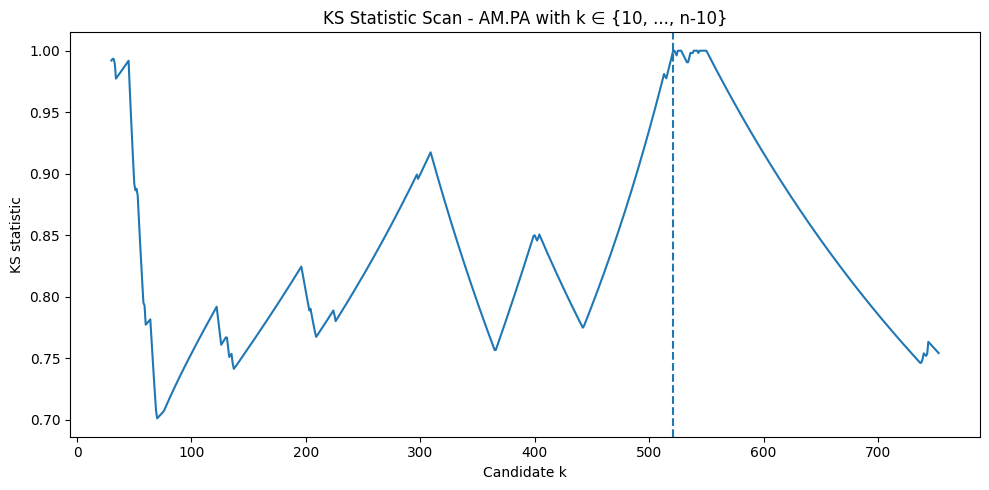

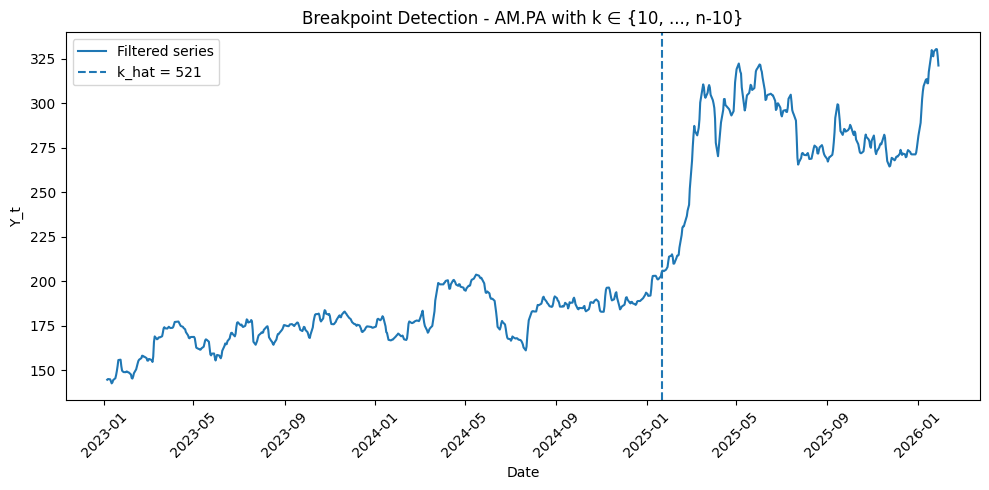

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(k_values, ks_stats)
plt.axvline(k_hat, linestyle="--")
plt.title("KS Statistic Scan - AM.PA with k ∈ {10, ..., n-10}")
plt.xlabel("Candidate k")
plt.ylabel("KS statistic")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(ampa_df["Date"], ampa_df["Y_t"], label="Filtered series")
plt.axvline(break_date, linestyle="--", label=f"k_hat = {k_hat}")
plt.title("Breakpoint Detection - AM.PA with k ∈ {10, ..., n-10}")
plt.xlabel("Date")
plt.ylabel("Y_t")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### 5. Split and Estimate Skew Normal Parameters

In [18]:
y1 = Y[:k_hat]
y2 = Y[k_hat:]

print("\nSegment sizes")
print("Before rupture:", len(y1))
print("After rupture :", len(y2))

def skew_normal_pdf(x, mu, sigma, theta):
    z = (x - mu) / sigma
    return (2.0 / sigma) * norm.pdf(z) * norm.cdf(theta * z)


def neg_loglik_common_theta(params, y_left, y_right):
    """
    params = [mu1, log_sigma1, mu2, log_sigma2, theta]
    sigma1 = exp(log_sigma1), sigma2 = exp(log_sigma2)
    Common theta across both segments, as required by Sujet 3.
    """
    mu1, log_sigma1, mu2, log_sigma2, theta = params

    sigma1 = np.exp(log_sigma1)
    sigma2 = np.exp(log_sigma2)

    # Safety against invalid values
    if sigma1 <= 0 or sigma2 <= 0 or not np.isfinite(theta):
        return np.inf

    pdf1 = skew_normal_pdf(y_left, mu1, sigma1, theta)
    pdf2 = skew_normal_pdf(y_right, mu2, sigma2, theta)

    # Numerical stability
    eps = 1e-12
    pdf1 = np.clip(pdf1, eps, None)
    pdf2 = np.clip(pdf2, eps, None)

    ll = np.sum(np.log(pdf1)) + np.sum(np.log(pdf2))
    return -ll



Segment sizes
Before rupture: 521
After rupture : 262


In [19]:
# Initial values
mu1_init = float(np.mean(y1))
mu2_init = float(np.mean(y2))
sigma1_init = float(np.std(y1, ddof=0))
sigma2_init = float(np.std(y2, ddof=0))

# Avoid zero std
sigma1_init = max(sigma1_init, 1e-3)
sigma2_init = max(sigma2_init, 1e-3)

theta_init = 0.0

x0 = np.array([
    mu1_init,
    np.log(sigma1_init),
    mu2_init,
    np.log(sigma2_init),
    theta_init
])

result = minimize(
    neg_loglik_common_theta,
    x0=x0,
    args=(y1, y2),
    method="L-BFGS-B"
)

if not result.success:
    print("\nWarning: optimization did not fully converge.")
    print("Message:", result.message)

mu1_hat, log_sigma1_hat, mu2_hat, log_sigma2_hat, theta_hat = result.x
sigma1_hat = float(np.exp(log_sigma1_hat))
sigma2_hat = float(np.exp(log_sigma2_hat))
mu1_hat = float(mu1_hat)
mu2_hat = float(mu2_hat)
theta_hat = float(theta_hat)

print("\nJoint MLE estimates with common theta")
print("mu1    =", mu1_hat)
print("sigma1 =", sigma1_hat)
print("mu2    =", mu2_hat)
print("sigma2 =", sigma2_hat)
print("theta  =", theta_hat)
print("NegLogLik =", float(result.fun))


Joint MLE estimates with common theta
mu1    = 177.02536938579655
sigma1 = 13.323479710677802
mu2    = 281.7541084923664
sigma2 = 27.706883646058998
theta  = 0.0
NegLogLik = 3330.4532850706582


In [20]:
verdict = "Reject H0" if best_pval < 0.05 else "Fail to reject H0"

print("\nVerdict:", verdict)


Verdict: Reject H0


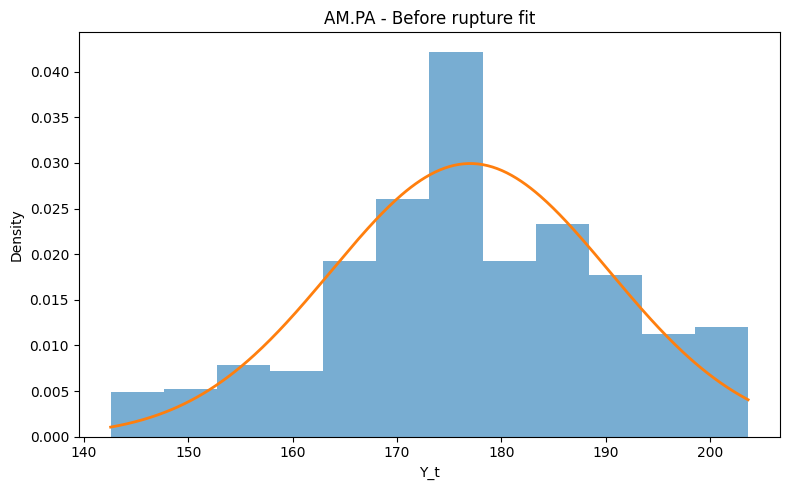

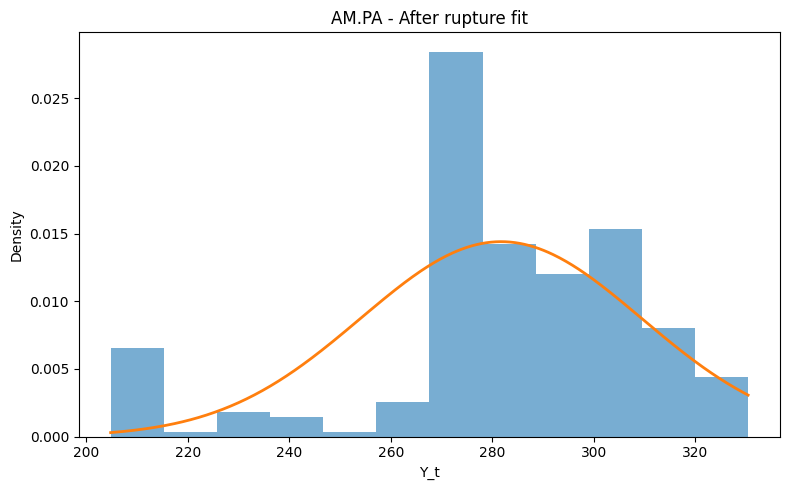

In [21]:
def plot_segment_fit(data, mu, sigma, theta, title):
    x_grid = np.linspace(np.min(data), np.max(data), 400)
    y_pdf = skew_normal_pdf(x_grid, mu, sigma, theta)

    plt.figure(figsize=(8, 5))
    plt.hist(data, bins=12, density=True, alpha=0.6)
    plt.plot(x_grid, y_pdf, linewidth=2)
    plt.title(title)
    plt.xlabel("Y_t")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

plot_segment_fit(y1, mu1_hat, sigma1_hat, theta_hat, f"AM.PA - Before rupture fit")
plot_segment_fit(y2, mu2_hat, sigma2_hat, theta_hat, f"AM.PA - After rupture fit")

### Interpretation

In [22]:
def build_interpretation_short(company):
    return (
        f"For {company}, the estimated rupture point is k_hat = {k_hat} "
        f"({break_date.date()}). The KS statistic is {best_ks:.4f} and the "
        f"p-value is {best_pval:.4f}, so the decision is: {verdict}. "
        f"The joint MLE estimates are mu1 = {mu1_hat:.4f}, sigma1 = {sigma1_hat:.4f}, "
        f"mu2 = {mu2_hat:.4f}, sigma2 = {sigma2_hat:.4f}, theta = {theta_hat:.4f}."
    )
interpretation= build_interpretation_short("AM.PA")

For AM.PA, the estimated rupture point is k_hat = 520 (2025-01-21). The KS statistic is 1.0000 and the p-value is 0.0000, so the decision is: Reject H0. The joint MLE estimates are mu1 = 177.0877, sigma1 = 13.2601, mu2 = 281.6030, sigma2 = 27.6519, theta = 0.0000.

**Save Result as JSON**

In [23]:
results = {
    "company": "AM.PA",
    "k_hat": int(k_hat),
    "break_date": str(break_date.date()),
    "ks_statistic": float(best_ks),
    "p_value": float(best_pval),
    "mu1": float(mu1_hat),
    "sigma1": float(sigma1_hat),
    "mu2": float(mu2_hat),
    "sigma2": float(sigma2_hat),
    "theta": float(theta_hat),
    "verdict": verdict,
    "interpretation": interpretation
}

with open("AM.PA.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4, ensure_ascii=False)